## Model API

The `VCO_Model` class encapsulates all relevant relationships:

- `fosc_from_vin(v_in)` – compute oscillation frequency for a given input voltage
- `vin_from_fosc(f_osc)` – invert the model to extract input voltage
- `conductance(v_in, i_dc)` – calculate conductance from voltage and current
- `dG_df(v_in, i_dc)` – dG/d(f_osc) at a given operating point; quantifies G uncertainty due to f_osc measurement error
- `dG_df_curve(i_dc_range)` – matrix of G tolerances (dG/d(f_osc)) across a range of currents and voltages

You can instantiate the model with your measured datasets and then call these methods directly for analysis or testing, independent of the plotting routines.

# PoI Plotter

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
from scipy.optimize import curve_fit
import warnings
import pandas as pd
warnings.filterwarnings('ignore')

## VCO_Model class

In [2]:
from VCO_model import VCO_Model

# instantiate the model with our data
VCO_model = VCO_Model(data_folder="data")


In [3]:
# from pannels import plot_fosc_model
# plot_fosc_model(VCO_model, mode="fit"

In [4]:
import matplotlib.pyplot as plt
from ipywidgets import FloatSlider, VBox, HBox, Layout, HTML, interactive_output
from IPython.display import display

from pannels import *
from workflow import compute_workflow


def PoI_plotter2():
    # Controls
    f_osc_slider = FloatSlider(
        value=820, min=0, max=1200, step=10,
        description='f_osc (kHz):',
        continuous_update=True,
        layout=Layout(width='300px')
    )
    i_dc_slider = FloatSlider(
        value=1.0, min=0.1, max=10, step=0.1,
        description='i_dc (μA):',
        continuous_update=True,
        layout=Layout(width='300px')
    )
    fs_Hz_slider = FloatSlider(
        value=1, min=0.5, max=20, step=0.5,
        description='fs (Hz):',
        continuous_update=True,
        layout=Layout(width='300px')
    )

    controls = VBox(
        [
            HTML("<h4>Controls</h4>"),
            f_osc_slider,
            i_dc_slider,
            fs_Hz_slider,
        ],
        layout=Layout(
            width='320px',
            padding='10px',
            border='1px solid #ddd'
        )
    )

    controls_wrapper = VBox(
        [controls],
        layout=Layout(
            width='340px',
            min_width='340px',
            height='850px',
            justify_content='center'
        )
    )

    def plot_workflow(f_osc_measured_kHz, i_dc_uA, fs_Hz):
        result = compute_workflow(VCO_model, f_osc_measured_kHz, i_dc_uA, fs_Hz)

        fig = plt.figure(figsize=(12, 10), constrained_layout=True)
        gs = fig.add_gridspec(3, 2)

        plot_fosc_model(VCO_model, mode="measurement", ax=fig.add_subplot(gs[0, 0]), result=result)
        plot_vin_text(fig.add_subplot(gs[0, 1]), VCO_model, result)
        # plot_G_vs_idc(fig.add_subplot(gs[1, 0]), result)
        plot_conductance_text(fig.add_subplot(gs[1, 0]), result)
        plot_df_osc_components(fig.add_subplot(gs[1, 1]), VCO_model, result, fs_Hz)
        plot_delta_G(fig.add_subplot(gs[2, 0]), VCO_model, result, fs_Hz)
        plot_power(fig.add_subplot(gs[2, 1]), VCO_model, result)

        fig.suptitle(
            'Integrated Measurement Workflow: $f_{osc} \\rightarrow V_{in} \\rightarrow G$',
            fontsize=14,
            fontweight='bold'
        )
        plt.show()

        print_analysis(VCO_model, result)

    interactive_plot = interactive_output(
        plot_workflow,
        {
            'f_osc_measured_kHz': f_osc_slider,
            'i_dc_uA': i_dc_slider,
            'fs_Hz': fs_Hz_slider
        }
    )

    display(HBox([controls_wrapper, interactive_plot], layout=Layout(align_items='center')))
# PoI_plotter2()

In [5]:
# !pip install ipympl
%matplotlib widget

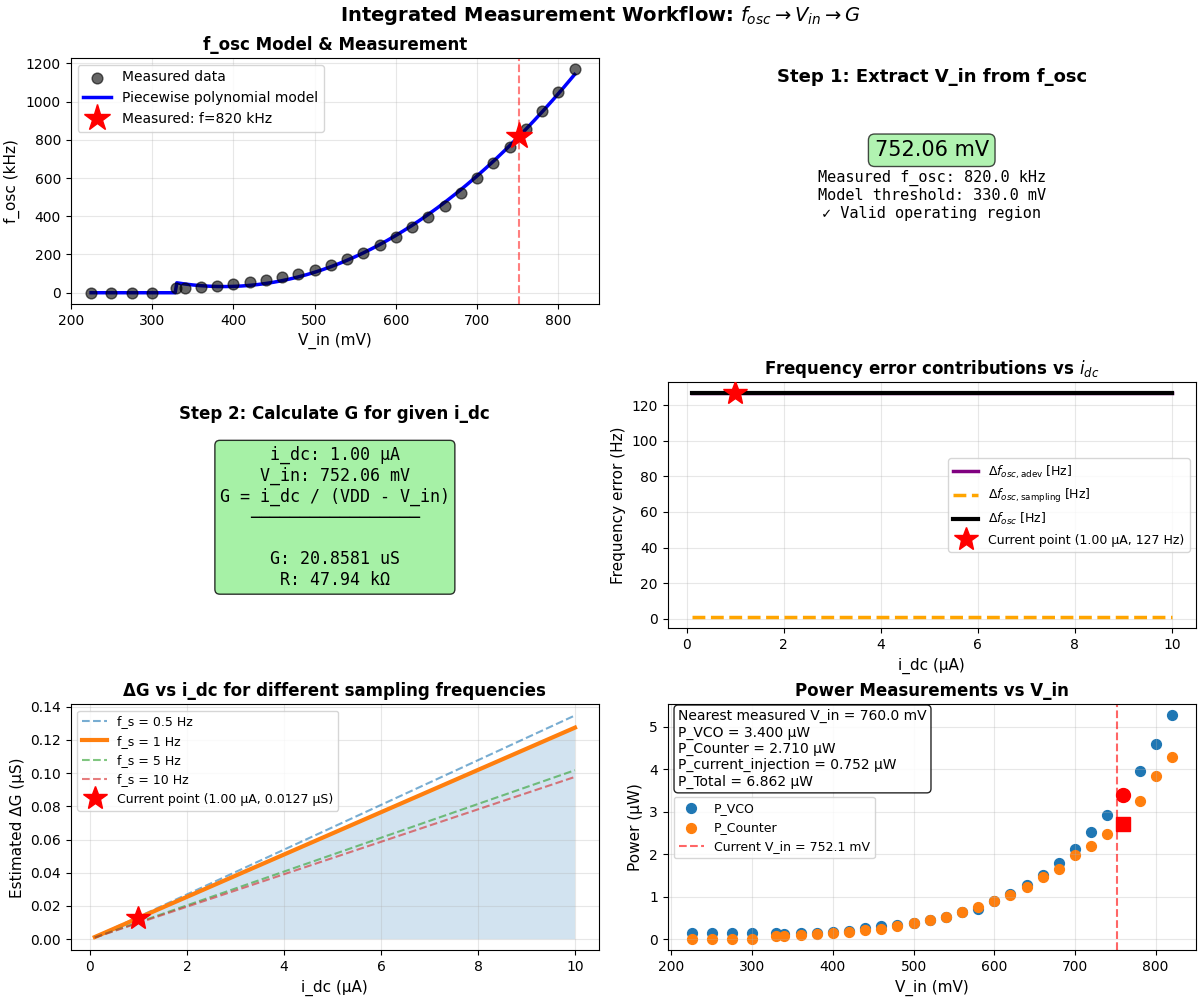

In [9]:
from ipywidgets import FloatSlider, VBox, HBox, Layout, HTML, widgets
from IPython.display import display

from pannels import *
from workflow import compute_workflow

def PoI_plotter(VCO_model):
        # Controls
    f_osc_slider = FloatSlider(
        value=820, min=0, max=1200, step=10,
        description='f_osc (kHz):',
        continuous_update=True,
        layout=Layout(width='300px')
    )
    i_dc_slider = FloatSlider(
        value=1.0, min=0.1, max=10, step=0.1,
        description='i_dc (μA):',
        continuous_update=True,
        layout=Layout(width='300px')
    )
    fs_Hz_slider = FloatSlider(
        value=1, min=0.5, max=20, step=0.5,
        description='fs (Hz):',
        continuous_update=True,
        layout=Layout(width='300px')
    )

    controls = VBox(
        [
            HTML("<h4>Controls</h4>"),
            f_osc_slider,
            i_dc_slider,
            fs_Hz_slider,
        ],
        layout=Layout(
            width='320px',
            padding='10px',
            border='1px solid #ddd'
        )
    )

    controls_wrapper = VBox(
        [controls],
        layout=Layout(
            width='340px',
            min_width='340px',
            height='850px',
            justify_content='center'
        )
    )


    # Create figure ONCE
    fig = plt.figure(figsize=(12, 10), constrained_layout=True)
    gs = fig.add_gridspec(3, 2)

    axes = {
        'fosc':        fig.add_subplot(gs[0, 0]),
        'vin':         fig.add_subplot(gs[0, 1]),
        'conductance': fig.add_subplot(gs[1, 0]),
        'df_osc':      fig.add_subplot(gs[1, 1]),
        'delta_g':     fig.add_subplot(gs[2, 0]),
        'power':       fig.add_subplot(gs[2, 1]),
    }

    fig.suptitle(
        'Integrated Measurement Workflow: $f_{osc} \\rightarrow V_{in} \\rightarrow G$',
        fontsize=14, fontweight='bold'
    )

    out_text = widgets.Output()

    out = fig.canvas  

    def update(change=None):
        result = compute_workflow(
            VCO_model,
            f_osc_slider.value,
            i_dc_slider.value,
            fs_Hz_slider.value
        )

        for ax in axes.values():
            ax.cla()

        plot_fosc_model(VCO_model, mode="measurement", ax=axes['fosc'],        result=result)
        plot_vin_text(                                  axes['vin'],  VCO_model, result)
        plot_conductance_text(                          axes['conductance'],     result)
        plot_df_osc_components(                        axes['df_osc'], VCO_model, result, fs_Hz_slider.value)
        plot_delta_G(                                  axes['delta_g'], VCO_model, result, fs_Hz_slider.value)
        plot_power(                                    axes['power'],  VCO_model, result)

        fig.canvas.draw_idle()

        out_text.clear_output(wait=True)
        with out_text:
            print_analysis(VCO_model, result)

    for slider in [f_osc_slider, i_dc_slider, fs_Hz_slider]:
        slider.observe(update, names='value')

    update()  # initial draw

    display(VBox([
        HBox([controls_wrapper, fig.canvas], layout=Layout(align_items='center')),
        out_text
    ]))
PoI_plotter(VCO_model)